# **Decision Trees**

## **The Data**

We will work with the "Palmer Penguins" dataset, as it is simple enough to help us fully understand how changing hyperparameters can change classification results.


Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

Gorman KB, Williams TD, Fraser WR (2014) Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis). PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081

Summary:
The data folder contains two CSV files. For intro courses/examples, you probably want to use the first one (penguins_size.csv).

* penguins_size.csv: Simplified data from original penguin data sets. Contains variables:

    * species: penguin species (Chinstrap, Adélie, or Gentoo)
    * culmen_length_mm: culmen length (mm)
    * culmen_depth_mm: culmen depth (mm)
    * flipper_length_mm: flipper length (mm)
    * body_mass_g: body mass (g)
    * island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
    * sex: penguin sex

* (Not used) penguins_lter.csv: Original combined data for 3 penguin species  

Note: The culmen is "the upper ridge of a bird's beak"

**Our goal is to create a model that can help predict a species of a penguin based on physical attributes, then we can use that model to help researchers classify penguins in the field, instead of needing an experienced biologist**

## **EDA**

**Import libraries and data**

In [ ]:
# Do not run this

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### **Missing Data**

Recall the purpose is to create a model for future use, so data points missing crucial information won't help in this task, especially since for future data points we will assume the research will grab the relevant feature information.

Check for missing data & the sum of that.

In [ ]:
# Do not run this

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
# Do not run this

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


Check What percentage are missing and we may drop?

In [ ]:
# What percentage are we dropping?
# Do not run this

2.9069767441860463

Seems ok to drop!

Check data one more time.

In [ ]:
# Do not run this

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


Check the uniqueness!

In [ ]:
# Do not run this

array(['MALE', 'FEMALE', '.'], dtype=object)

We want to only keep 'MALE' and 'FEMALE'

In [ ]:
# Do not run this

array(['MALE', 'FEMALE'], dtype=object)

## **Visualization**

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

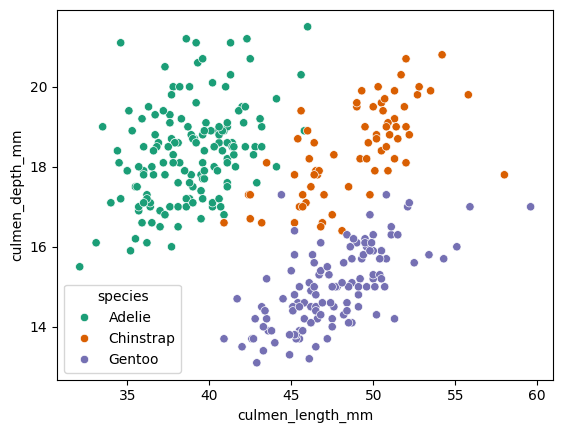

In [ ]:
# Do not run this

/tmp/ipykernel_425/1926922542.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='species',y='culmen_length_mm',data=df,kind='box',col='sex',palette='Dark2')


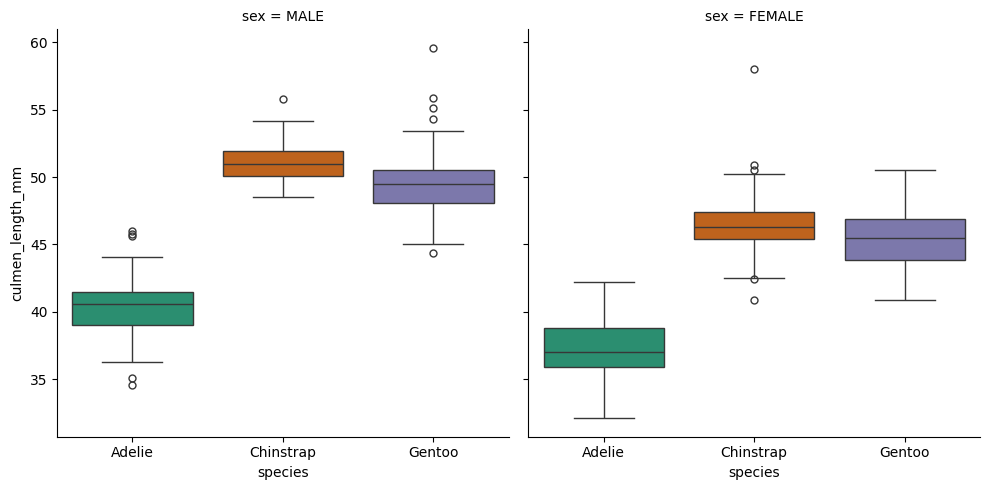

In [ ]:
# Do not run this

## **Feature Engineering**

Perform one-hot encoding, but make sure to drop 'species' before the get_dummies function is applied as species is likely your target variable (what you want to predict), and you don't want to use it as a feature (input) for the model itself.

Alternatively, you can first separate data into X and y then perform one-hot encoding

## **Train | Test Split**

## **Decision Tree Classifier**

### **Default Hyperparameters**

Create the Decision Tree model and fit it to the data and predict

In [ ]:
# Do not run this

DecisionTreeClassifier()

## **Evaluation**

In [ ]:
# Do not run this

array([[38,  2,  0],
       [ 1, 26,  0],
       [ 1,  0, 32]])

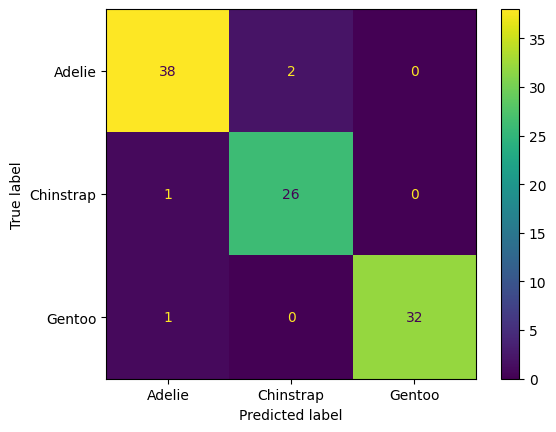

In [ ]:
# Do not run this

In [ ]:
# Do not run this

              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        40
   Chinstrap       0.93      0.96      0.95        27
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



Show model feature importances

In [ ]:
# Do not run this

array([0.33350103, 0.02010577, 0.60147473, 0.        , 0.03806069,
       0.00685778, 0.        ])

In [ ]:
# Do not run this

,Feature Importance
culmen_length_mm,0.333501
culmen_depth_mm,0.020106
flipper_length_mm,0.601475
body_mass_g,0.000000
island_Dream,0.038061
island_Torgersen,0.006858
sex_MALE,0.000000


## **Visualize the Tree**


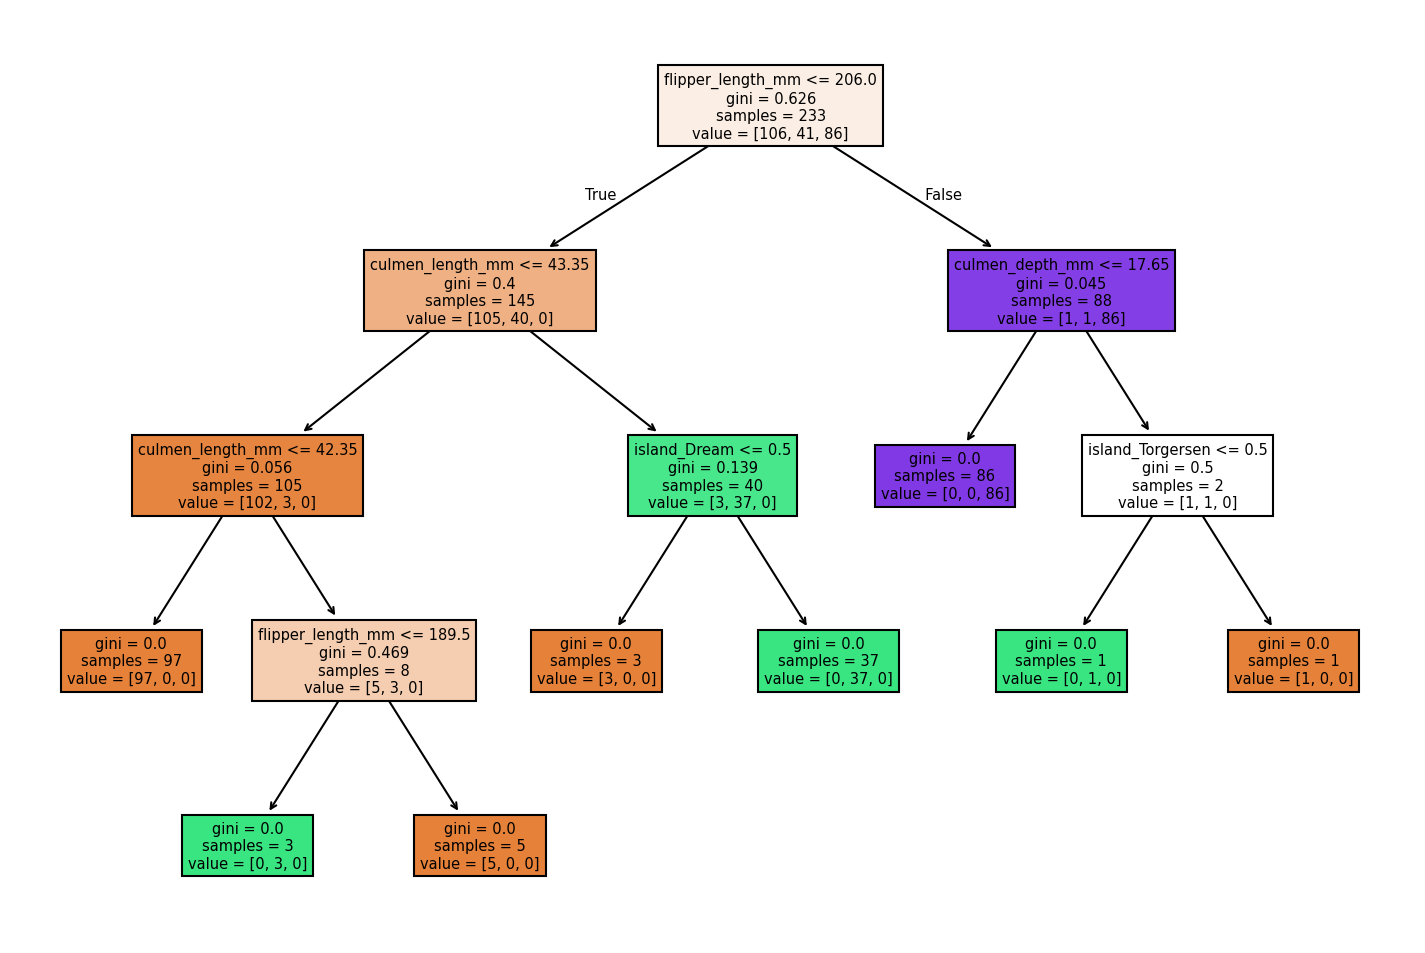

In [ ]:
# Do not run this

## **Reporting Model Results**

To begin experimenting with hyperparameters, let's create a function that reports back classification results and plots out the tree.

In [ ]:
def report_model(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(model,filled=True,feature_names=X.columns);

## **Understanding Hyperparameters**

## **Max Leaf Nodes**

Change Max Leaf Nodes to 3 and call the report_model function to see the result

In [ ]:
# Do not run this

DecisionTreeClassifier(max_leaf_nodes=3)

              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        40
   Chinstrap       0.91      0.78      0.84        27
      Gentoo       0.86      0.97      0.91        33

    accuracy                           0.91       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.91      0.91       100





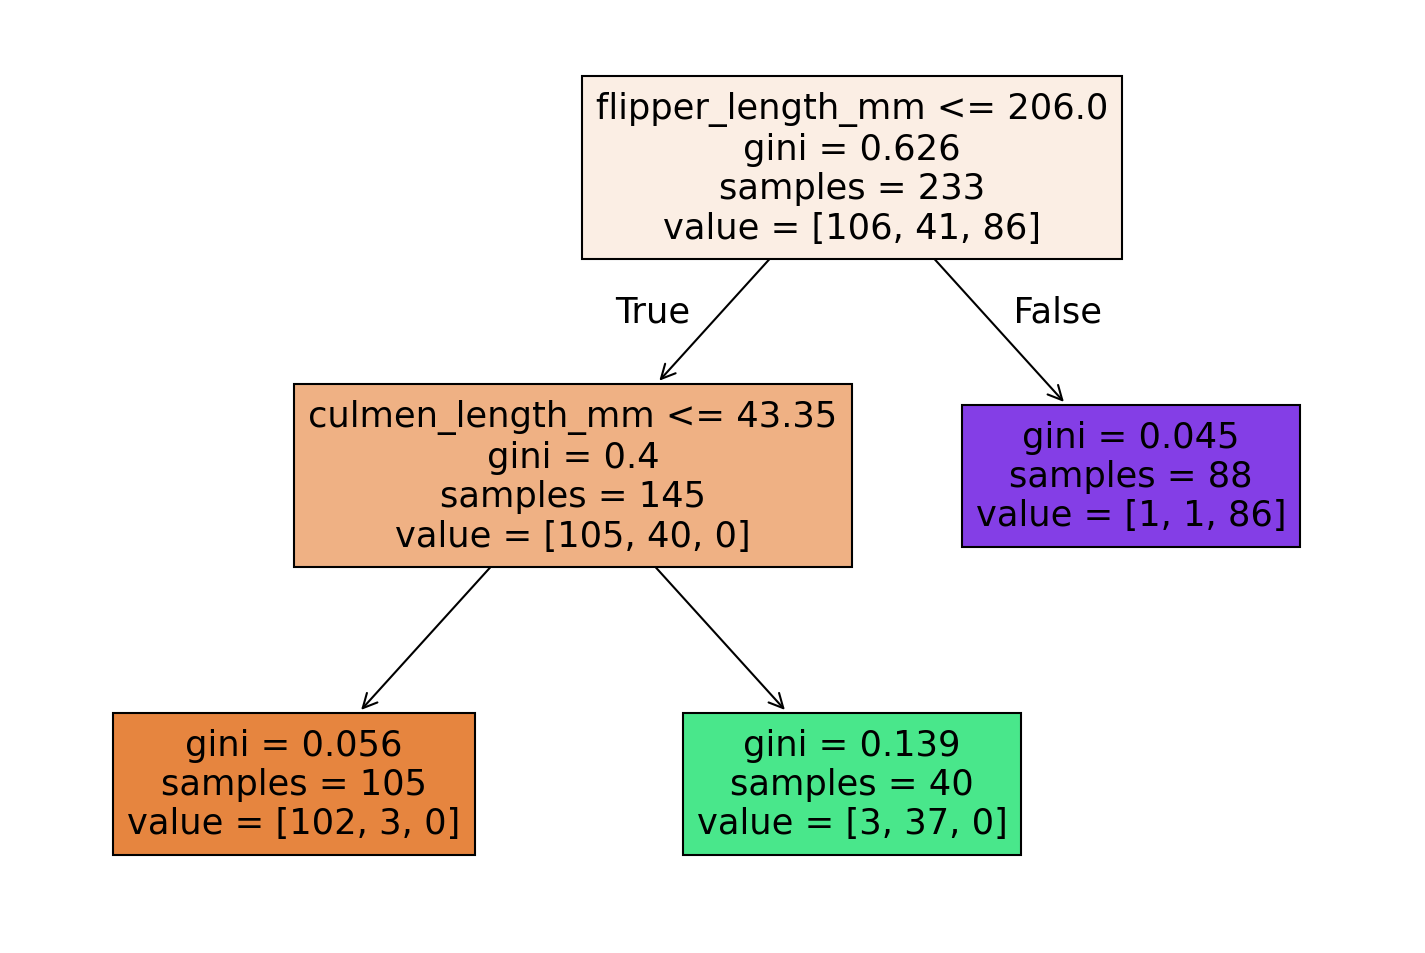

In [ ]:
# Do not run this

## **Criterion**

Use entropy and check the results

In [ ]:
# Do not run this

DecisionTreeClassifier(criterion='entropy')

              precision    recall  f1-score   support

      Adelie       0.91      0.97      0.94        40
   Chinstrap       0.96      0.89      0.92        27
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.95       100
   macro avg       0.96      0.94      0.95       100
weighted avg       0.95      0.95      0.95       100





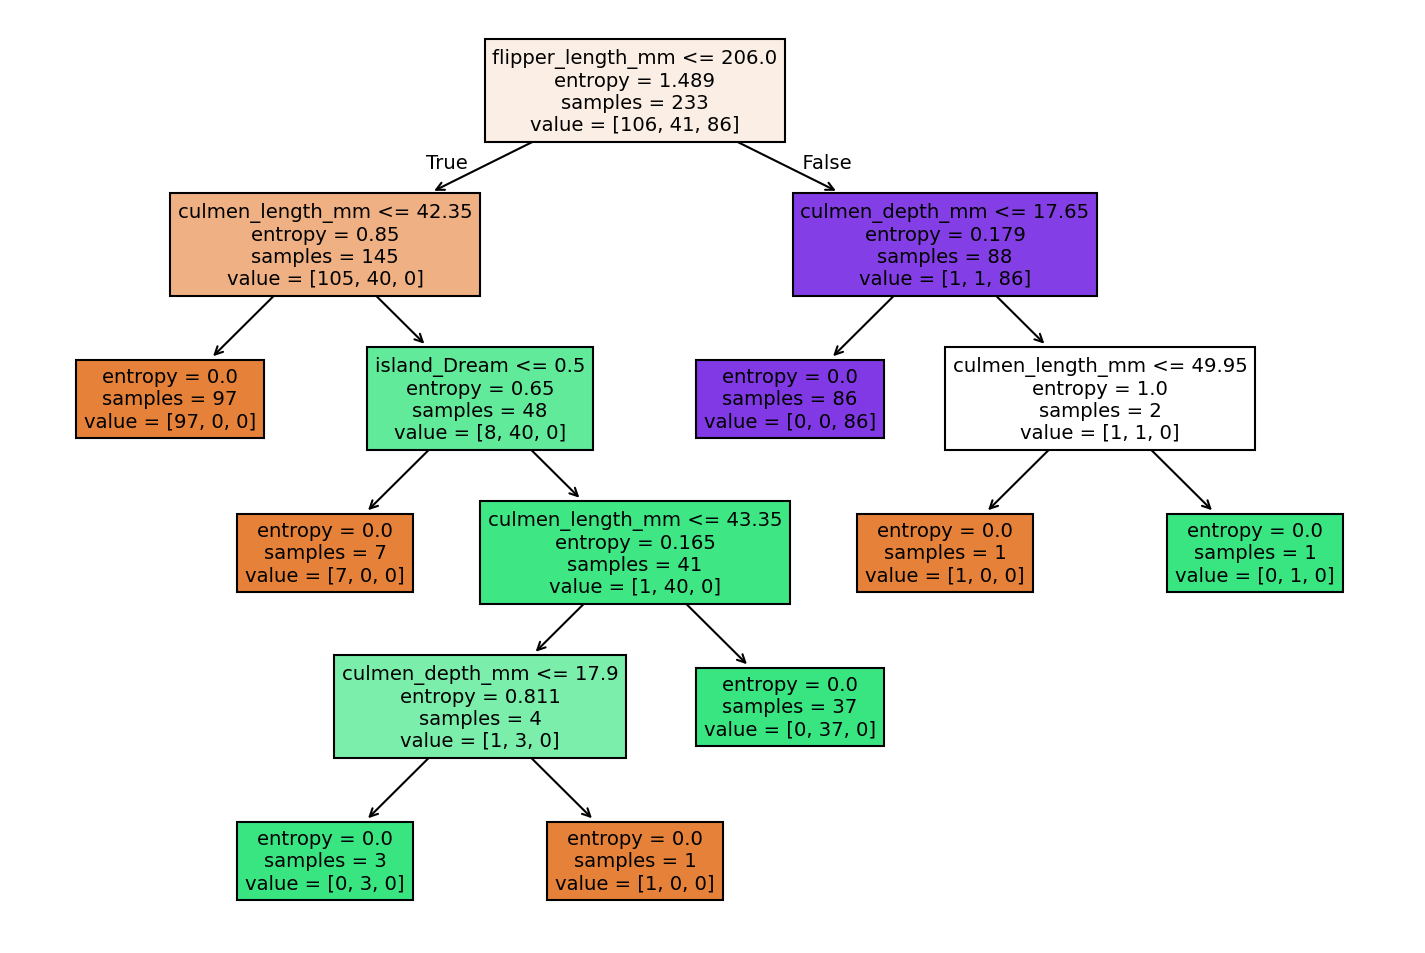

In [ ]:
# Do not run this

<br><br>

# **Random Forest Classification**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
 |  The sub-sample size is controlled with the `max_samples` parameter i

Creat a Random Forest model, use 5 random trees, 'sqrt' for max features and 101 as random seed

In [ ]:
# Use 5 random trees
# Do not run this

RandomForestClassifier(n_estimators=5, random_state=101)

Predict

## **Evaluation**

In [ ]:
# Do not run this

              precision    recall  f1-score   support

      Adelie       0.95      0.97      0.96        40
   Chinstrap       0.96      0.96      0.96        27
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [ ]:
# Do not run this

array([[39,  1,  0],
       [ 1, 26,  0],
       [ 1,  0, 32]])

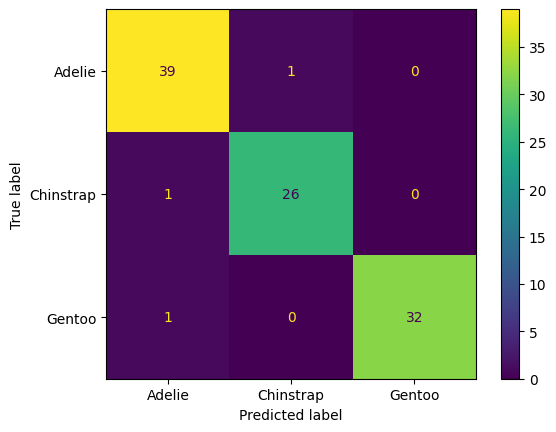

In [ ]:
# Do not run this

## **Feature Importance**


In [ ]:
# Do not run this

array([0.44837785, 0.13383078, 0.17593048, 0.11249954, 0.11648521,
       0.00981917, 0.00305698])

## **Choosing correct number of trees**

Perform Grid search using:

    n_estimators=[4, 8,32,64]

    max_features= [2,3,4]

    bootstrap = [True,False]

    oob_score = [True,False]

In [ ]:
# Do not run this

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [4, 8, 32, 64],
                         'oob_score': [True, False]})

check the grid best parameters

In [ ]:
# Do not run this

{'bootstrap': True, 'max_features': 2, 'n_estimators': 32, 'oob_score': True}

In [ ]:
# Do not run this

              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        40
   Chinstrap       1.00      0.96      0.98        27
      Gentoo       1.00      1.00      1.00        33

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



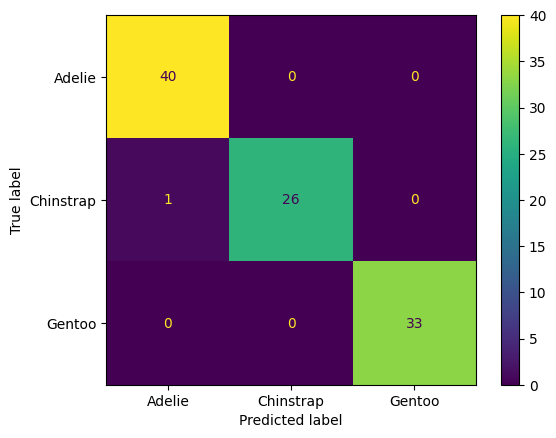

In [ ]:
# Do not run this

Report the best estimator's OOB Score

In [ ]:
# Do not run this

0.9957081545064378